In [9]:
from src.data_loader import load_categories, save_raw, load_raw, raw_data_exists
from src.preprocessing import preprocess, save_processed, load_processed, processed_data_exists
from src.sentiment import load_model, predict, filter_low_confidence, save_with_sentiment, load_with_sentiment, sentiment_data_exists
from src.mismatch import classify, summary, summary_by_rating, sample_mismatches, save_classified, load_classified, classified_data_exists
from src.analysis import plot_mismatch_by_category, plot_mismatch_by_rating, plot_mismatch_direction, save_summary_tables, qualitative_table
from src.analysis import sentiment_confusion_matrix, chi_square_category_test, chi_square_rating_test, confidence_comparison, mismatch_direction_table, review_length_analysis

from IPython.display import display
import pandas as pd

In [10]:
FORCE_RELOAD = True

In [11]:
if (not raw_data_exists() or FORCE_RELOAD):
	df_raw = load_categories(["Electronics", "Clothing", "Books", "Home_and_Kitchen", "Sports_and_Outdoors", "Automotive"], n_samples_per_category=50000)
	save_raw(df_raw)
else:
	print("Raw data already exists. Skipping streaming step.")
	df_raw = load_raw()

[Electronics] Connecting to HuggingFace...
[Electronics] Sampling 50000 reviews...
[Electronics] Done — 50,000 reviews loaded.
[Clothing] Connecting to HuggingFace...
[Clothing] Sampling 50000 reviews...
[Clothing] Done — 50,000 reviews loaded.
[Books] Connecting to HuggingFace...
[Books] Sampling 50000 reviews...
[Books] Done — 50,000 reviews loaded.
[Home_and_Kitchen] Connecting to HuggingFace...
[Home_and_Kitchen] Sampling 50000 reviews...
[Home_and_Kitchen] Done — 50,000 reviews loaded.
[Sports_and_Outdoors] Connecting to HuggingFace...
[Sports_and_Outdoors] Sampling 50000 reviews...
[Sports_and_Outdoors] Done — 50,000 reviews loaded.
[Automotive] Connecting to HuggingFace...
[Automotive] Sampling 50000 reviews...
[Automotive] Done — 50,000 reviews loaded.

Total reviews loaded: 300,000
category
Electronics            50000
Clothing               50000
Books                  50000
Home_and_Kitchen       50000
Sports_and_Outdoors    50000
Automotive             50000

Raw data saved

In [12]:
if (not processed_data_exists() or FORCE_RELOAD):
	df_clean = preprocess(df_raw)
	save_processed(df_clean)
else:
	print("Processed data already exists. Skipping preprocessing step.")
	df_clean = load_processed()

Starting preprocessing pipeline...
  Input: 300,000 reviews

  [drop_missing] 300,000 → 299,932  (removed 68 = 0.0%)
  [drop_duplicates] 299,932 → 62,799  (removed 237,133 = 79.1%)
  [drop_short (< 10 words)] 62,799 → 45,805  (removed 16,994 = 27.1%)


Detecting language: 100%|██████████| 45805/45805 [01:31<00:00, 498.12it/s]


  [filter_english] 45,805 → 45,668  (removed 137 = 0.3%)

Preprocessing complete.
  Output: 45,668 reviews

Rating sentiment distribution:
rating_sentiment
positive    35271
negative     6819
neutral      3578

By category:
category             rating_sentiment
Automotive           positive            8902
                     negative            1799
                     neutral              836
Books                positive            4318
                     negative             570
                     neutral              394
Clothing             positive            3194
                     negative             575
                     neutral              429
Electronics          positive            6230
                     negative            1529
                     neutral              665
Home_and_Kitchen     positive            3099
                     negative             643
                     neutral              310
Sports_and_Outdoors  positive            9528
  

In [13]:
if (not sentiment_data_exists() or FORCE_RELOAD):
	classifier = load_model()
	df_sentiment = predict(df_clean, classifier)
	df_sentiment = filter_low_confidence(df_sentiment, threshold=0.60)
	save_with_sentiment(df_sentiment)
else:
	print("Sentiment data already exists. Skipping sentiment analysis step.")
	df_sentiment = load_with_sentiment()

Loading sentiment model on CPU...
  Model : cardiffnlp/twitter-roberta-base-sentiment-latest
  Batch size: 32


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.

Running sentiment analysis on 45,668 reviews...


Sentiment inference:   0%|          | 0/1428 [00:00<?, ?batch/s]


Prediction complete.
Text sentiment distribution:
text_sentiment
positive    32060
negative     8885
neutral      4723

Mean confidence score: 0.829
[filter_low_confidence (threshold=0.6)] 45,668 → 38,934  (removed 6,734 = 14.7%)
Saved to data/processed/reviews_with_sentiment.parquet  (38,934 rows)


In [14]:
if (not classified_data_exists() or FORCE_RELOAD):
	df_classified = classify(df_sentiment)
	save_classified(df_classified)
else:
	print("Classified data already exists. Skipping classification step.")
	df_classified = load_classified()

Mismatch classification complete.

Overall mismatch rate: 12.2%

Mismatch type counts:
mismatch_type
match              34176
soft_mismatch       3550
strong_mismatch     1208
Saved classified data to data/processed/reviews_with_mismatch.parquet  (38,934 rows)


Saved figure → results/figures/mismatch_by_category.png / .pdf
Saved figure → results/figures/mismatch_by_rating.png / .pdf


/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:329: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
/Users/vicvsl/dev/tudelft/WebSciEng/src/analysis.py:82: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(out, bbox_inches="tight")


Saved figure → results/figures/mismatch_direction_by_category.png / .pdf
Saved summary_by_category  → results/tables
Saved summary_by_rating    → results/tables


,category,Stars,Rating sentiment,Text sentiment,Confidence,Direction,Review excerpt
0,Home_and_Kitchen,2.0,negative,positive,0.7446,text_more_positive,I like the item as I already have a set. I bro...
1,Electronics,4.0,positive,negative,0.8318,text_more_negative,"This is very a esthetically pleasing, but is n..."
2,Sports_and_Outdoors,4.0,positive,negative,0.8387,text_more_negative,They were not as sturdy as I was hoping for. B...
3,Books,4.0,positive,negative,0.6961,text_more_negative,I was afraid of reading this book because I re...
4,Automotive,5.0,positive,negative,0.7130,text_more_negative,Didn't realize the repair shop put the wrong b...
5,Home_and_Kitchen,5.0,positive,negative,0.7851,text_more_negative,Can't review now as I'm not going to put this ...
6,Automotive,5.0,positive,negative,0.8802,text_more_negative,"Check with your state though, I got pulled ove..."
7,Clothing,2.0,negative,positive,0.7406,text_more_positive,I was so excited to order these earrings becau...
8,Automotive,4.0,positive,negative,0.6380,text_more_negative,The clip could be a little longer. Keeps falli...
9,Electronics,5.0,positive,negative,0.9185,text_more_negative,It never unfolded and took shape like the othe...


/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  func(*args, **kwargs)


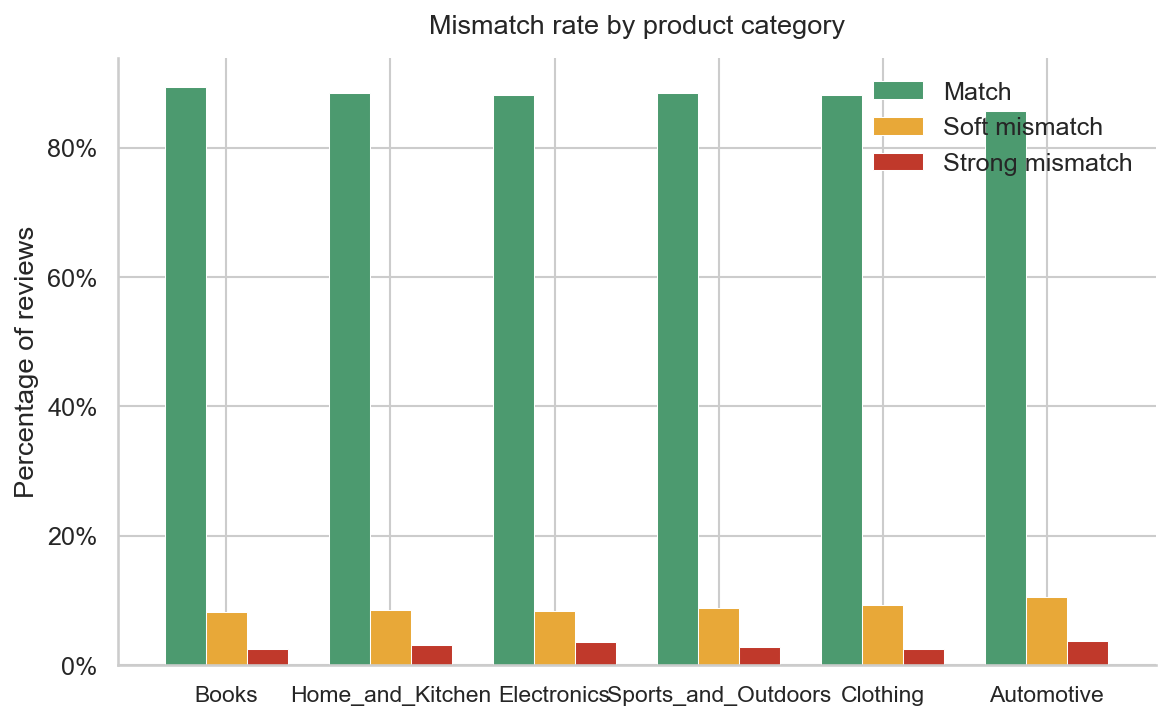

/Users/vicvsl/dev/tudelft/WebSciEng/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


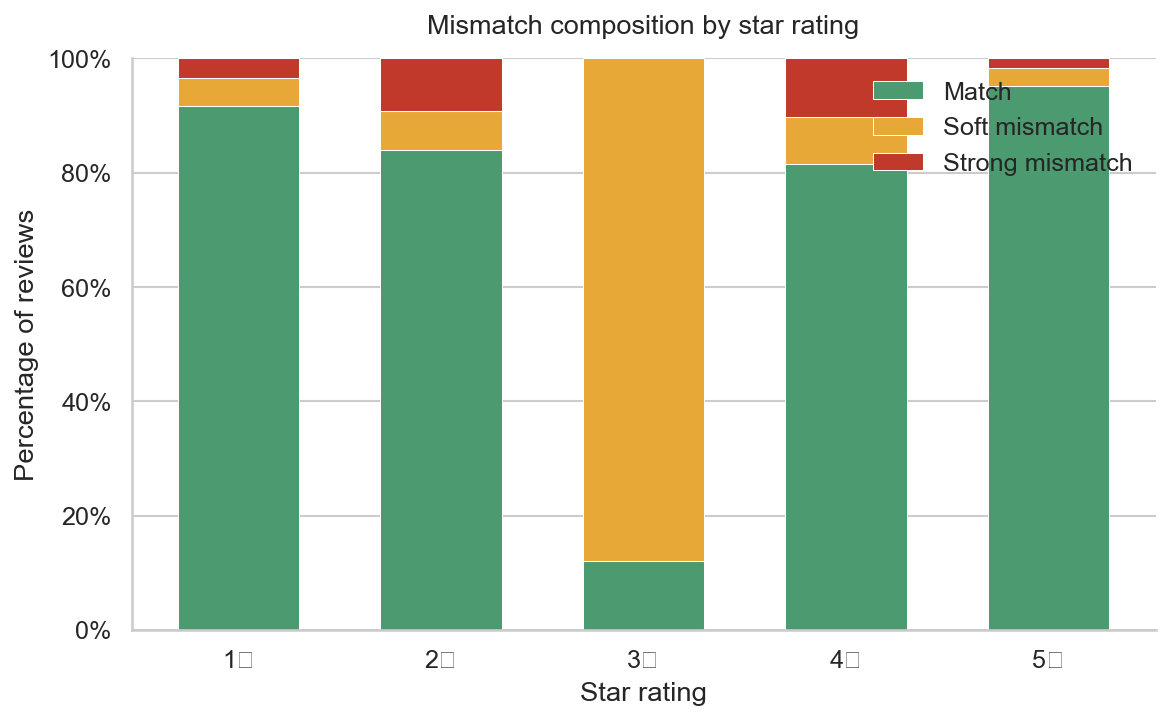

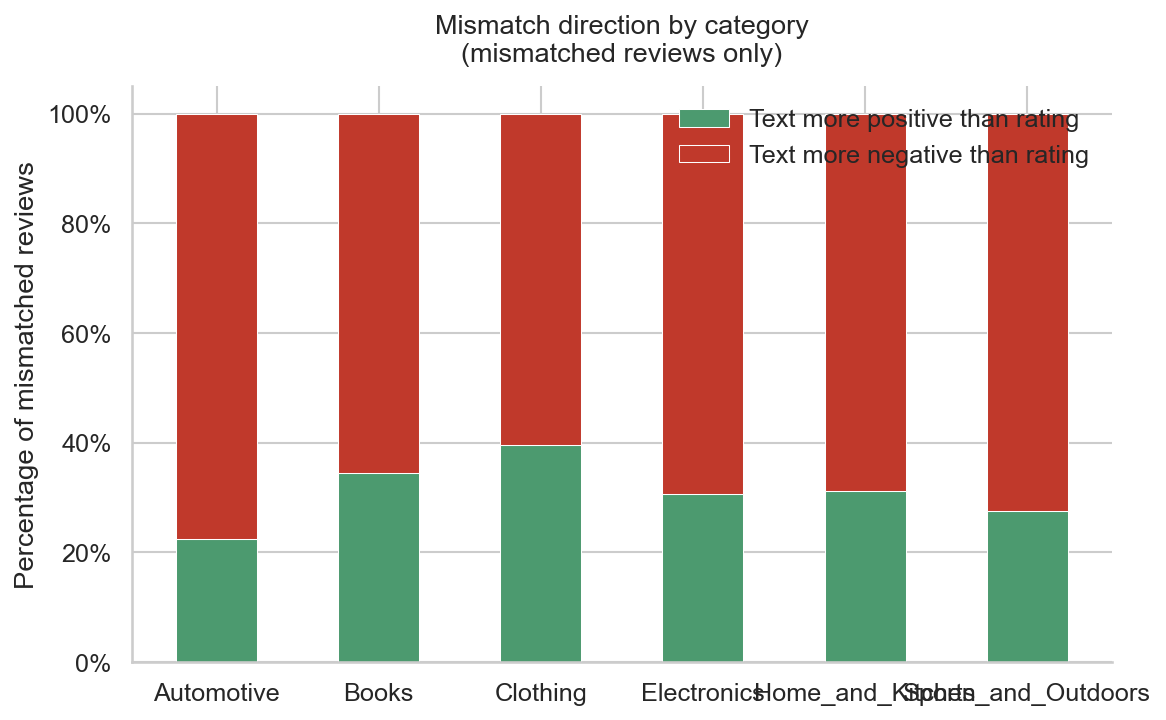

In [15]:
df = df_classified.copy()
plot_mismatch_by_category(df)
plot_mismatch_by_rating(df)
plot_mismatch_direction(df)
save_summary_tables(df)
qualitative_table(df)

In [16]:
print("CONFUSION MATRIX")
cm = sentiment_confusion_matrix(df)
display(cm)

print("CHI-SQUARE TEST: CATEGORY vs MISMATCH")
cat_stats = chi_square_category_test(df)
print(f"Chi-square : {cat_stats['chi2']:.4f}")
print(f"Degrees freedom : {cat_stats['dof']}")
print(f"P-value : {cat_stats['p']:.6f}")
print(f"Cramér's V : {cat_stats['cramers_v']:.4f}")
if cat_stats["p"] < 0.05:
    print("Result: Significant relationship between category and mismatch rate.")
else:
    print("Result: No significant relationship detected.")

print("CHI-SQUARE TEST: STAR RATING vs MISMATCH")
rating_stats = chi_square_rating_test(df)
print(f"Chi-square : {rating_stats['chi2']:.4f}")
print(f"Degrees freedom : {rating_stats['dof']}")
print(f"P-value : {rating_stats['p']:.6f}")
print(f"Cramér's V : {rating_stats['cramers_v']:.4f}")
if rating_stats["p"] < 0.05:
    print("Result: Significant relationship between rating and mismatch rate.")
else:
    print("Result: No significant relationship detected.")

print("CONFIDENCE SCORE COMPARISON")
conf = confidence_comparison(df)
print(f"Match mean confidence     : {conf['match_mean']:.4f}")
print(f"Mismatch mean confidence : {conf['mismatch_mean']:.4f}")
print(f"Mann-Whitney U           : {conf['u_statistic']:.4f}")
print(f"P-value                  : {conf['p']:.6f}")

print("MISMATCH DIRECTION BY CATEGORY (%)")
direction_table = mismatch_direction_table(df)
display(direction_table)

print("REVIEW LENGTH ANALYSIS")
length_stats = review_length_analysis(df)
print(f"Mean match length     : {length_stats['match_mean_length']:.2f} words")
print(f"Mean mismatch length  : {length_stats['mismatch_mean_length']:.2f} words")
print(f"Mann-Whitney U        : {length_stats['u_statistic']:.4f}")
print(f"P-value               : {length_stats['p']:.6f}")

summary = pd.DataFrame([
    {
        "Test": "Category vs Mismatch",
        "Statistic": cat_stats["chi2"],
        "p-value": cat_stats["p"],
        "Effect size": cat_stats["cramers_v"],
    },
    {
        "Test": "Rating vs Mismatch",
        "Statistic": rating_stats["chi2"],
        "p-value": rating_stats["p"],
        "Effect size": rating_stats["cramers_v"],
    },
])
display(summary.round(4))
summary.to_latex(
    "results/tables/statistical_tests.tex",
    index=False,
    float_format="%.4f"
)

CONFUSION MATRIX


text_sentiment,negative,neutral,positive
rating_sentiment,,,
negative,89.11,5.46,5.43
neutral,55.04,12.08,32.88
positive,2.91,3.93,93.16


CHI-SQUARE TEST: CATEGORY vs MISMATCH
Chi-square : 55.6786
Degrees freedom : 5
P-value : 0.000000
Cramér's V : 0.0378
Result: Significant relationship between category and mismatch rate.
CHI-SQUARE TEST: STAR RATING vs MISMATCH
Chi-square : 13903.8212
Degrees freedom : 4
P-value : 0.000000
Cramér's V : 0.5976
Result: Significant relationship between rating and mismatch rate.
CONFIDENCE SCORE COMPARISON
Match mean confidence     : 0.9024
Mismatch mean confidence : 0.7555
Mann-Whitney U           : 139090486.0000
P-value                  : 0.000000
MISMATCH DIRECTION BY CATEGORY (%)


mismatch_direction,text_more_positive,text_more_negative
category,,
Automotive,22.41,77.59
Books,34.52,65.48
Clothing,39.58,60.42
Electronics,30.70,69.30
Home_and_Kitchen,31.14,68.86
Sports_and_Outdoors,27.51,72.49


REVIEW LENGTH ANALYSIS
Mean match length     : 46.20 words
Mean mismatch length  : 63.82 words
Mann-Whitney U        : 72376423.0000
P-value               : 0.000000


,Test,Statistic,p-value,Effect size
0,Category vs Mismatch,55.6786,0.0,0.0378
1,Rating vs Mismatch,13903.8212,0.0,0.5976
